# Prévision de la consommation énergétique

**Projet Data Science — Python & Machine Learning**

L'objectif de ce projet est d'analyser la consommation énergétique d'un logement et d'étudier différentes approches de prédiction.

Le projet est organisé en deux parties :
1. une approche de régression classique avec séparation aléatoire des données ;
2. une approche de prévision temporelle respectant l'ordre chronologique des observations.

## 1. Initialisation de l'environnement

Cette section prépare l'environnement nécessaire à l'exécution du notebook.

- Connexion à Google Drive pour accéder aux données et aux fichiers du projet.
- Création automatique des dossiers nécessaires s'ils n'existent pas.
- Chargement du modèle Random Forest sauvegardé lorsqu'il est disponible.
- Préparation de l'environnement pour permettre une exécution complète du notebook depuis le début.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Chemin principal du projet dans Google Drive
project_path = '/content/drive/MyDrive/energy-consumption-data-science'

# Sous-dossiers persistants
data_dir = os.path.join(project_path, 'data')
models_dir = os.path.join(project_path, 'models')
notebooks_dir = os.path.join(project_path, 'notebooks')

os.makedirs(data_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(notebooks_dir, exist_ok=True)

# Chemins persistants des fichiers
DATA_PATH = os.path.join(data_dir, 'energydata_complete.csv')
MODEL_PATH = os.path.join(models_dir, 'best_random_forest.pkl')

# Vérification du dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'Dataset introuvable : {DATA_PATH}\n'
        'Place energydata_complete.csv dans le dossier data du projet Google Drive.'
    )

# Chargement des données
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

# Rechargement du modèle optimisé s'il existe déjà
if os.path.exists(MODEL_PATH):
    best_rf = joblib.load(MODEL_PATH)
    print('✓ Dataset chargé :', df.shape)
    print('✓ Modèle optimisé rechargé depuis Google Drive')
else:
    best_rf = None
    print('✓ Dataset chargé :', df.shape)
    print('ℹ Aucun modèle sauvegardé : le tuning sera exécuté plus bas.')

# Cette variable permettra de savoir si un GridSearch a été exécuté pendant cette session
grid_search = None


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset chargé : (19735, 29)
✓ Modèle optimisé rechargé depuis Google Drive


In [2]:
# Vérification : les données proviennent désormais directement de Google Drive
print('Source du dataset :', DATA_PATH)
print('Dimensions :', df.shape)


Source du dataset : /content/drive/MyDrive/energy-consumption-data-science/data/energydata_complete.csv
Dimensions : (19735, 29)


In [3]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.shape

(19735, 29)

In [5]:
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

In [7]:
df.isna().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["date"]=pd.to_datetime(df["date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

In [11]:
df["Appliances"].describe()

,Appliances
count,19735.000000
mean,97.694958
std,102.524891
min,10.000000
25%,50.000000
50%,60.000000
75%,100.000000
max,1080.000000


In [12]:
df["Appliances"].median()

60.0

**Interprétation:**

La consommation des appareils présente une forte variabilité. La moyenne est d’environ 97,7 Wh alors que la médiane est de 60 Wh, ce qui indique une distribution asymétrique avec une majorité de consommations relativement faibles et quelques pics élevés. Le maximum atteint 1080 Wh, très au-dessus du troisième quartile situé à 100 Wh, ce qui suggère la présence de valeurs extrêmes ou de périodes de forte consommation.

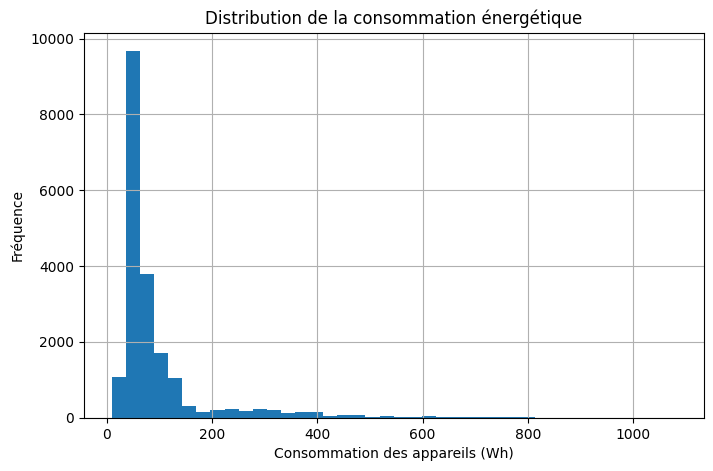

In [13]:
plt.figure(figsize=(8,5))
df["Appliances"].hist(bins=40)
plt.title("Distribution de la consommation énergétique")
plt.xlabel("Consommation des appareils (Wh)")
plt.ylabel("Fréquence")
plt.show()

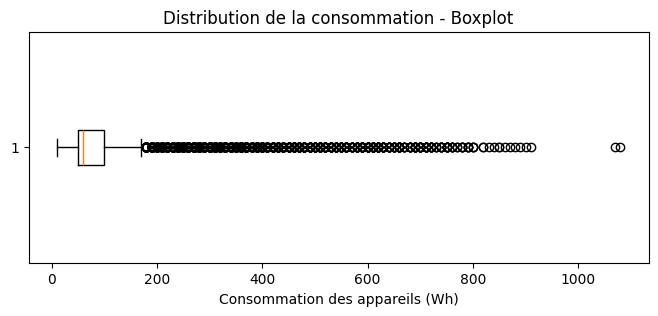

In [14]:
plt.figure(figsize=(8,3))

plt.boxplot(df["Appliances"], vert=False)

plt.title("Distribution de la consommation - Boxplot")
plt.xlabel("Consommation des appareils (Wh)")

plt.show()

**Interprétation:**

La variable Appliances présente une distribution fortement asymétrique à droite. La majorité des observations correspond à des niveaux de consommation faibles à modérés, tandis qu’un nombre plus limité de mesures présente des consommations élevées. Le boxplot met en évidence de nombreuses valeurs extrêmes, mais celles-ci peuvent représenter de véritables pics de consommation plutôt que des erreurs de mesure. Elles ne doivent donc pas être supprimées automatiquement sans analyse complémentaire.

In [15]:
df["Appliances"].sort_values(ascending=False).head(10)

,Appliances
731,1080
1451,1070
432,910
12088,900
1452,890
10668,880
14693,870
9031,860
1821,850
19582,850


In [16]:
corr = df.corr(numeric_only=True)

corr["Appliances"].sort_values(ascending=False)

,Appliances
Appliances,1.000000
lights,0.197278
T2,0.120073
T6,0.117638
T_out,0.099155
Windspeed,0.087122
RH_1,0.086031
T3,0.085060
T1,0.055447
T4,0.040281


In [17]:
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [18]:
df[["date", "hour", "day_of_week", "month", "is_weekend"]].head()

,date,hour,day_of_week,month,is_weekend
0,2016-01-11 17:00:00,17,0,1,0
1,2016-01-11 17:10:00,17,0,1,0
2,2016-01-11 17:20:00,17,0,1,0
3,2016-01-11 17:30:00,17,0,1,0
4,2016-01-11 17:40:00,17,0,1,0


In [19]:
hourly_consumption = df.groupby("hour")["Appliances"].mean()
hourly_consumption

,Appliances
hour,
0,52.785888
1,51.326034
2,49.075426
3,48.236010
4,49.355231
5,52.737226
6,57.712895
7,78.649635
8,106.143552


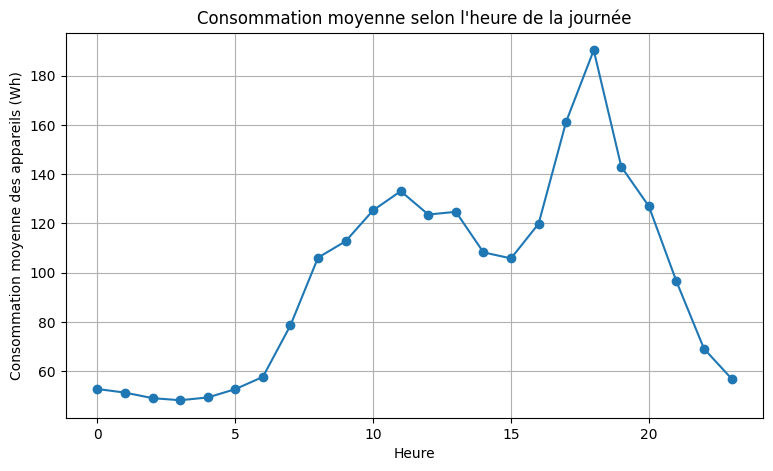

In [20]:
plt.figure(figsize=(9,5))
plt.plot(hourly_consumption.index, hourly_consumption.values, marker="o")

plt.title("Consommation moyenne selon l'heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Consommation moyenne des appareils (Wh)")
plt.grid(True)

plt.show()

**Interprétation:**

La consommation énergétique varie fortement selon l’heure de la journée. Elle reste faible durant la nuit, augmente à partir du matin, puis atteint son niveau maximal en début de soirée, autour de 18h. Cette évolution suggère que l’heure constitue une variable explicative importante, probablement liée aux habitudes d’occupation et d’utilisation des appareils dans le logement.

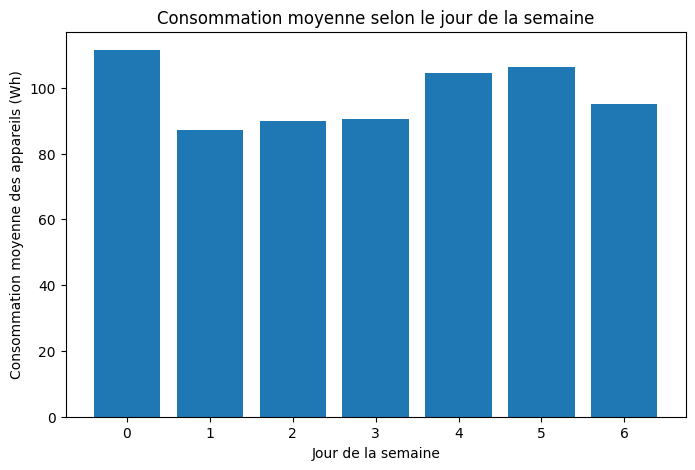

In [21]:
daily_consumption = df.groupby("day_of_week")["Appliances"].mean()

plt.figure(figsize=(8,5))
plt.bar(daily_consumption.index, daily_consumption.values)

plt.title("Consommation moyenne selon le jour de la semaine")
plt.xlabel("Jour de la semaine")
plt.ylabel("Consommation moyenne des appareils (Wh)")

plt.show()

**Interprétation:**

La consommation moyenne varie selon le jour de la semaine. Le lundi présente la consommation moyenne la plus élevée, tandis que les niveaux les plus faibles sont observés en début et milieu de semaine, notamment le mardi. Une hausse est également visible le vendredi et le samedi. L'effet du jour semble néanmoins moins marqué que celui de l'heure de la journée.

In [22]:
weekend_consumption = df.groupby("is_weekend")["Appliances"].mean()

weekend_consumption

,Appliances
is_weekend,
0,96.587674
1,100.581140


**Interprétation:**

La consommation moyenne est légèrement plus élevée le week-end (environ 100,6 Wh) que pendant les jours de semaine (environ 96,6 Wh). L’effet du week-end existe donc, mais il reste relativement modéré comparé à l’effet de l’heure de la journée.

In [23]:
monthly_consumption = df.groupby("month")["Appliances"].mean()

monthly_consumption

,Appliances
month,
1,97.026010
2,100.945881
3,96.953405
4,98.888889
5,94.199325


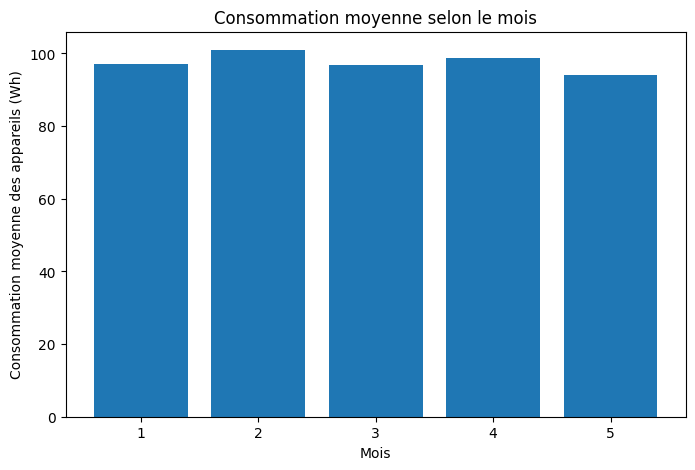

In [24]:
plt.figure(figsize=(8,5))
plt.bar(monthly_consumption.index, monthly_consumption.values)

plt.title("Consommation moyenne selon le mois")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne des appareils (Wh)")

plt.show()

**Interprétation:**

La consommation moyenne varie légèrement selon les mois observés, avec un niveau un peu plus élevé en février et un peu plus faible en mai. Cependant, les écarts restent modérés. Comme le jeu de données ne couvre qu’une partie de l’année, cette analyse ne permet pas de conclure à une saisonnalité annuelle complète.

In [25]:
# Variable cible
y = df["Appliances"]

In [26]:
X = df.drop(columns=["Appliances", "date", "rv1", "rv2"])

In [27]:
X.shape

(19735, 29)

In [28]:
y.shape

(19735,)

In [29]:
X.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day_of_week,month,is_weekend
0,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,17,0,1,0
1,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,17,0,1,0
2,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,17,0,1,0
3,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,17,0,1,0
4,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,17,0,1,0


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (15788, 29)
X_test : (3947, 29)
y_train : (15788,)
y_test : (3947,)


In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model_lr = LinearRegression()

In [35]:
model_lr.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred_lr = model_lr.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [38]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R² :", r2_lr)

MAE : 52.55120541378159
RMSE : 91.06973683778429
R² : 0.17121800034135626


En pratique, ça veut dire que la régression linéaire fait des erreurs moyennes assez importantes et explique seulement une partie limitée de la variabilité de la consommation. Le RMSE étant nettement supérieur à la MAE, ça indique aussi qu’il y a probablement quelques grosses erreurs de prédiction.

La suite logique est donc de tester un modèle capable de capturer des relations plus complexes et non linéaires. On peut passer à Random Forest Regressor et comparer directement ses MAE, RMSE et R² avec ceux de la régression linéaire.

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [41]:
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [42]:
y_pred_rf = model_rf.predict(X_test)

In [43]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

MAE : 30.930580187484164
RMSE : 66.11809550976463
R² : 0.5631495194010796


In [44]:
print("Régression linéaire")
print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R² :", r2_lr)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

Régression linéaire
MAE : 52.55120541378159
RMSE : 91.06973683778429
R² : 0.17121800034135626

Random Forest
MAE : 30.930580187484164
RMSE : 66.11809550976463
R² : 0.5631495194010796



- La MAE diminue d’environ 52,55 à 30,93 Wh ;
- le RMSE passe d’environ 91,07 à 66,12 Wh ;
- le R² passe d’environ 0,17 à 0,56.

Cela montre que le Random Forest capture beaucoup mieux les relations entre les variables explicatives et la consommation énergétique que la régression linéaire.

Ces résultats suggèrent que la relation entre les variables et `Appliances` n’est pas purement linéaire et qu’il existe probablement des interactions et des effets non linéaires entre la température, l’humidité, les variables temporelles et les autres caractéristiques.



In [45]:
import pandas as pd

feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
hour,0.151718
T3,0.062380
RH_3,0.045292
Press_mm_hg,0.041610
RH_5,0.040663
RH_2,0.038717
T8,0.037749
Tdewpoint,0.034184
RH_1,0.034048
RH_4,0.032963


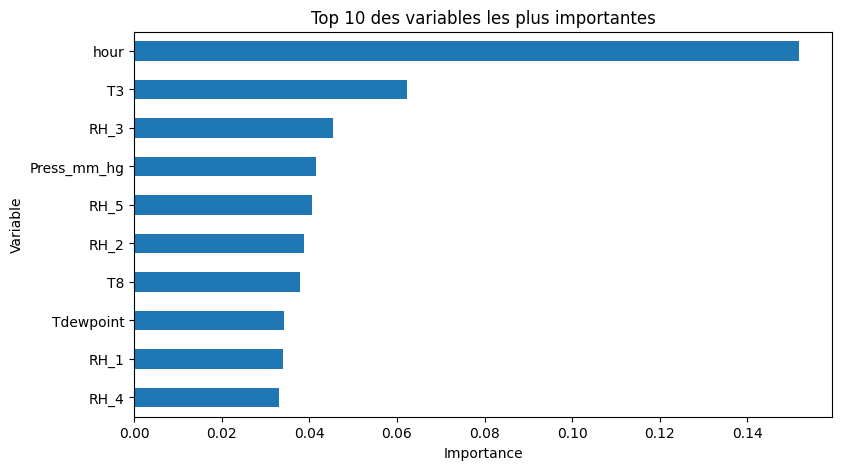

In [46]:
plt.figure(figsize=(9,5))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.show()

L’analyse des importances de variables montre que plusieurs mesures d’humidité, notamment RH_out et RH_1, jouent un rôle important dans les prédictions de la Random Forest. La pression atmosphérique, certaines températures et la consommation des lumières contribuent également au modèle. Ces importances doivent cependant être interprétées comme une mesure de contribution au modèle et non comme une relation causale directe avec la consommation énergétique.

In [47]:
from sklearn.inspection import permutation_importance

In [48]:
perm_importance = permutation_importance(
    model_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

In [50]:
perm_series = pd.Series(
    perm_importance.importances_mean,
    index=X.columns
).sort_values(ascending=False)

perm_series.head(10)

,0
hour,0.631450
T3,0.408154
month,0.331392
RH_3,0.183572
lights,0.163354
T4,0.108848
T8,0.092400
Press_mm_hg,0.083220
T9,0.080327
RH_4,0.068487


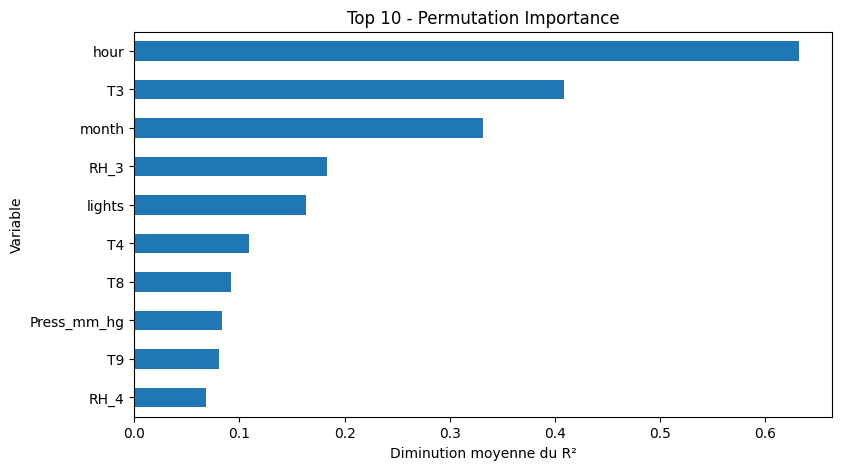

In [51]:
plt.figure(figsize=(9,5))

perm_series.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 - Permutation Importance")
plt.xlabel("Diminution moyenne du R²")
plt.ylabel("Variable")

plt.show()

La permutation importance confirme que plusieurs variables d’humidité jouent un rôle central dans les prédictions du modèle. RH_8 et RH_out apparaissent comme les variables dont la perturbation entraîne la plus forte baisse du R². RH_1, lights et RH_2 ont également une contribution importante. Le classement diffère partiellement de celui obtenu avec l’importance interne de la Random Forest, ce qui montre l’intérêt de comparer plusieurs méthodes d’interprétation.

In [52]:
from sklearn.model_selection import GridSearchCV

In [53]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5]
}

In [54]:
if best_rf is None:
    grid_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=2
    )
else:
    print('✓ best_rf est déjà disponible : GridSearch non recréé.')


✓ best_rf est déjà disponible : GridSearch non recréé.


In [55]:
if best_rf is None:
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    joblib.dump(best_rf, MODEL_PATH)
    print('✓ GridSearch terminé et meilleur modèle sauvegardé dans Google Drive.')
else:
    print('✓ Modèle sauvegardé déjà chargé : GridSearch ignoré.')


✓ Modèle sauvegardé déjà chargé : GridSearch ignoré.


In [56]:
best_params = {
    'n_estimators': best_rf.get_params()['n_estimators'],
    'max_depth': best_rf.get_params()['max_depth'],
    'min_samples_split': best_rf.get_params()['min_samples_split']
}
best_params


{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}

In [57]:
if grid_search is not None and hasattr(grid_search, 'best_score_'):
    print('Meilleur R² moyen du GridSearch :', grid_search.best_score_)
else:
    print('GridSearch non recalculé pendant cette session ; le modèle sauvegardé est utilisé.')


GridSearch non recalculé pendant cette session ; le modèle sauvegardé est utilisé.


In [58]:
# Le meilleur modèle est maintenant disponible dans best_rf
best_rf


RandomForestRegressor(n_estimators=200, random_state=42)

In [59]:
y_pred_best_rf = best_rf.predict(X_test)

In [60]:
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("MAE :", mae_best_rf)
print("RMSE :", rmse_best_rf)
print("R² :", r2_best_rf)

MAE : 30.77988345578921
RMSE : 65.84268968265624
R² : 0.5667812210464613


Le tuning des hyperparamètres du Random Forest améliore légèrement les performances du modèle.  
Le R² passe d’environ 0,563 à 0,567, tandis que la MAE diminue légèrement d’environ 30,93 à 30,78 Wh et que le RMSE passe d’environ 66,12 à 65,84 Wh.

L’amélioration reste faible, ce qui montre que le modèle Random Forest initial était déjà proche d’une bonne configuration. Le tuning apporte donc un gain supplémentaire, mais limité.



In [61]:
best_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 200,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [62]:
# Rappel des hyperparamètres du modèle optimisé
best_params


{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}

In [63]:
from sklearn.model_selection import cross_val_score

In [64]:
cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [65]:
print("Scores R² :", cv_scores)
print("R² moyen :", cv_scores.mean())
print("Écart-type :", cv_scores.std())

Scores R² : [-0.80049816 -0.12683778  0.12545131  0.14468183 -4.54694904]
R² moyen : -1.0408303687464204
Écart-type : 1.7861501780881341


La séparation train/test aléatoire donnait un R² d'environ 0,56, ce qui pouvait laisser penser que le modèle généralisait correctement.

Cependant, la validation croisée montre une forte instabilité des performances selon les sous-échantillons : les scores R² varient fortement et le R² moyen devient négatif.

Cela indique que les bonnes performances obtenues avec le split aléatoire ne sont pas suffisamment robustes. Comme les observations sont ordonnées dans le temps, une validation classique n'est pas idéale.

Nous utilisons donc ensuite `TimeSeriesSplit`, qui respecte l'ordre chronologique des données et permet d'évaluer plus justement la capacité du modèle à prédire des observations futures à partir du passé.

In [66]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [67]:
tscv = TimeSeriesSplit(n_splits=5)

In [68]:
ts_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

In [69]:
print("Scores TimeSeriesSplit :", ts_scores)
print("R² moyen :", ts_scores.mean())
print("Écart-type :", ts_scores.std())

Scores TimeSeriesSplit : [-0.77692297 -0.16155284 -0.83282548 -0.54108009 -5.36296506]
R² moyen : -1.535069286987251
Écart-type : 1.9284854258930824


### Conclusion de la validation temporelle

Malgré de bonnes performances lors d'une séparation aléatoire des données, le Random Forest présente des scores R² négatifs lors de la validation temporelle.

Cela montre que le modèle actuel généralise mal lorsqu'il doit prédire des observations futures à partir des données passées.

Le modèle est néanmoins conservé comme modèle de référence. La suite du projet consiste à reformuler le problème en prévision temporelle en ajoutant des variables historiques de consommation (`lag features`).

### Sauvegarde persistante du meilleur modèle Random Forest

Le meilleur modèle est conservé dans Google Drive afin qu'une nouvelle session Colab puisse le recharger automatiquement.  
Ainsi, le `GridSearchCV` n'a pas besoin d'être relancé à chaque reprise du projet.


In [70]:
# Sauvegarde / mise à jour du modèle dans Google Drive
joblib.dump(best_rf, MODEL_PATH)
print('Modèle sauvegardé :', MODEL_PATH)


Modèle sauvegardé : /content/drive/MyDrive/energy-consumption-data-science/models/best_random_forest.pkl


In [71]:
# Vérification du contenu du dossier models
os.listdir(models_dir)


['best_random_forest.pkl']

## Prévision temporelle avec des variables retardées

La validation temporelle a montré que le modèle actuel généralise mal lorsqu'il doit prédire des observations futures à partir du passé.

Pour mieux tenir compte de la structure temporelle des données, nous allons maintenant créer des variables retardées (`lag features`) basées sur la consommation passée.

L'objectif est de fournir au modèle des informations telles que :
- la consommation 10 minutes auparavant ;
- la consommation 1 heure auparavant ;
- la consommation 24 heures auparavant ;
- la consommation moyenne de la dernière heure.

In [77]:
df["Appliances_lag_1"] = df["Appliances"].shift(1)
df["Appliances_lag_6"] = df["Appliances"].shift(6)
df["Appliances_lag_144"] = df["Appliances"].shift(144)

df["rolling_mean_6"] = df["Appliances"].shift(1).rolling(6).mean()

In [78]:
df[
    [
        "date",
        "Appliances",
        "Appliances_lag_1",
        "Appliances_lag_6",
        "Appliances_lag_144",
        "rolling_mean_6"
    ]
].head(10)

,date,Appliances,Appliances_lag_1,Appliances_lag_6,Appliances_lag_144,rolling_mean_6
0,2016-01-11 17:00:00,60,NaN,NaN,NaN,NaN
1,2016-01-11 17:10:00,60,60.0,NaN,NaN,NaN
2,2016-01-11 17:20:00,50,60.0,NaN,NaN,NaN
3,2016-01-11 17:30:00,50,50.0,NaN,NaN,NaN
4,2016-01-11 17:40:00,60,50.0,NaN,NaN,NaN
5,2016-01-11 17:50:00,50,60.0,NaN,NaN,NaN
6,2016-01-11 18:00:00,60,50.0,60.0,NaN,55.000000
7,2016-01-11 18:10:00,60,60.0,60.0,NaN,55.000000
8,2016-01-11 18:20:00,60,60.0,50.0,NaN,55.000000
9,2016-01-11 18:30:00,70,60.0,50.0,NaN,56.666667


### Préparation des données pour le forecasting

La création des variables retardées génère naturellement des valeurs manquantes au début de la série, car aucune observation passée n'est disponible pour calculer certains retards.

Par exemple, `Appliances_lag_144` nécessite 144 observations antérieures, soit 24 heures de données.

Nous supprimons donc uniquement les lignes pour lesquelles les variables historiques nécessaires ne sont pas encore disponibles avant de construire le modèle de prévision.

In [79]:
df_forecast = df.dropna(
    subset=[
        "Appliances_lag_1",
        "Appliances_lag_6",
        "Appliances_lag_144",
        "rolling_mean_6"
    ]
).copy()

In [80]:
print("Taille initiale :", df.shape)
print("Taille forecasting :", df_forecast.shape)

Taille initiale : (19735, 37)
Taille forecasting : (19591, 37)


In [81]:
df_forecast[
    [
        "Appliances_lag_1",
        "Appliances_lag_6",
        "Appliances_lag_144",
        "rolling_mean_6"
    ]
].isna().sum()

,0
Appliances_lag_1,0
Appliances_lag_6,0
Appliances_lag_144,0
rolling_mean_6,0


### Préparation des variables pour le modèle de forecasting

Après avoir créé les variables historiques de consommation et supprimé les lignes incomplètes, nous pouvons maintenant construire un nouveau jeu de variables explicatives adapté à la prévision temporelle.

La cible reste `Appliances`, tandis que les nouvelles variables retardées et la moyenne glissante sont ajoutées aux variables explicatives.

In [82]:
y_forecast = df_forecast["Appliances"]

X_forecast = df_forecast.drop(
    columns=["Appliances", "date", "rv1", "rv2"]
)

In [83]:
print("Shape X_forecast :", X_forecast.shape)
print("Shape y_forecast :", y_forecast.shape)

print(X_forecast.columns)

Shape X_forecast : (19591, 33)
Shape y_forecast : (19591,)
Index(['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5',
       'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour',
       'day_of_week', 'month', 'is_weekend', 'Appliances_lag_1',
       'Appliances_lag_6', 'Appliances_lag_144', 'rolling_mean_6'],
      dtype='object')


### Séparation chronologique des données

Comme l'objectif est maintenant de prédire des observations futures, nous ne devons plus mélanger aléatoirement les données.

Nous allons donc utiliser les premières observations pour entraîner le modèle et conserver la dernière partie de la série comme jeu de test.

Cette séparation respecte l'ordre chronologique et simule mieux une situation réelle de prévision.

In [84]:
split_index = int(len(df_forecast) * 0.8)

X_train_forecast = X_forecast.iloc[:split_index]
X_test_forecast = X_forecast.iloc[split_index:]

y_train_forecast = y_forecast.iloc[:split_index]
y_test_forecast = y_forecast.iloc[split_index:]

In [85]:
print("X_train_forecast :", X_train_forecast.shape)
print("X_test_forecast :", X_test_forecast.shape)

print("y_train_forecast :", y_train_forecast.shape)
print("y_test_forecast :", y_test_forecast.shape)

X_train_forecast : (15672, 33)
X_test_forecast : (3919, 33)
y_train_forecast : (15672,)
y_test_forecast : (3919,)


### Vérification du découpage temporel

Avant d'entraîner le modèle, nous vérifions que le jeu d'entraînement contient bien les observations les plus anciennes et que le jeu de test contient les observations les plus récentes.

Cette vérification permet de s'assurer que le modèle apprend uniquement à partir du passé avant d'être évalué sur une période future.

In [86]:
train_start = df_forecast["date"].iloc[0]
train_end = df_forecast["date"].iloc[split_index - 1]

test_start = df_forecast["date"].iloc[split_index]
test_end = df_forecast["date"].iloc[-1]

print("Période d'entraînement :", train_start, "→", train_end)
print("Période de test :", test_start, "→", test_end)

Période d'entraînement : 2016-01-12 17:00:00 → 2016-04-30 12:50:00
Période de test : 2016-04-30 13:00:00 → 2016-05-27 18:00:00


### Validation du découpage temporel

Le jeu d'entraînement contient les observations les plus anciennes, tandis que le jeu de test correspond à la période la plus récente.

Cette séparation respecte l'ordre chronologique des données et évite que le modèle puisse apprendre à partir d'informations futures.

Nous pouvons maintenant entraîner un modèle de forecasting sur les données passées puis évaluer sa capacité à prédire la consommation sur une période future.

In [87]:
from sklearn.ensemble import RandomForestRegressor

model_rf_forecast = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_rf_forecast.fit(
    X_train_forecast,
    y_train_forecast
)

y_pred_forecast = model_rf_forecast.predict(
    X_test_forecast
)

### Évaluation du modèle de forecasting

Le modèle Random Forest a été entraîné uniquement sur la période passée et utilisé pour prédire la consommation sur une période future.

Nous allons maintenant mesurer ses performances avec les mêmes métriques que précédemment : MAE, RMSE et R², afin de comparer cette approche temporelle à l'approche initiale.

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_forecast = mean_absolute_error(
    y_test_forecast,
    y_pred_forecast
)

rmse_forecast = np.sqrt(
    mean_squared_error(
        y_test_forecast,
        y_pred_forecast
    )
)

r2_forecast = r2_score(
    y_test_forecast,
    y_pred_forecast
)

print("MAE Forecast :", mae_forecast)
print("RMSE Forecast :", rmse_forecast)
print("R² Forecast :", r2_forecast)

MAE Forecast : 82.7912094922174
RMSE Forecast : 114.50871599093371
R² Forecast : -0.6999317593632746


### Interprétation des premiers résultats de forecasting

L'ajout de variables retardées de consommation améliore la représentation temporelle du problème, mais les performances restent faibles sur la période future.

Le modèle obtient un R² négatif d'environ -0,70, ce qui signifie qu'il fait moins bien qu'une prédiction naïve basée sur la moyenne du jeu de test.

La MAE et le RMSE restent également élevés, ce qui montre que certaines variations de consommation sont encore mal capturées.

Cette première tentative confirme qu'une simple combinaison de quelques lag features avec un Random Forest ne suffit pas encore. Nous allons donc approfondir le feature engineering temporel et comparer le modèle à une baseline simple avant d'essayer d'autres améliorations.

### Construction d'une baseline naïve

Avant de chercher à améliorer davantage le modèle de forecasting, nous allons le comparer à une règle très simple.

La baseline naïve consiste à prédire que la consommation actuelle sera égale à la consommation observée 10 minutes auparavant.

Cette comparaison permet de vérifier si le modèle Random Forest apporte réellement une valeur ajoutée par rapport à une stratégie très simple.

In [90]:
y_pred_naive = X_test_forecast["Appliances_lag_1"]

In [91]:
mae_naive = mean_absolute_error(
    y_test_forecast,
    y_pred_naive
)

rmse_naive = np.sqrt(
    mean_squared_error(
        y_test_forecast,
        y_pred_naive
    )
)

r2_naive = r2_score(
    y_test_forecast,
    y_pred_naive
)

print("MAE baseline naïve :", mae_naive)
print("RMSE baseline naïve :", rmse_naive)
print("R² baseline naïve :", r2_naive)

MAE baseline naïve : 26.047461087011992
RMSE baseline naïve : 65.1850761806153
R² baseline naïve : 0.44912793089918557


### Comparaison avec la baseline naïve

La baseline naïve, qui prédit simplement que la consommation actuelle sera égale à celle observée 10 minutes auparavant, obtient de meilleures performances que le premier modèle Random Forest de forecasting.

La baseline atteint un R² d'environ 0,45 avec une MAE d'environ 26 Wh, alors que le Random Forest obtient un R² négatif et des erreurs nettement plus élevées.

Cela montre que la consommation présente une forte dépendance à très court terme et qu'un modèle complexe ne garantit pas de meilleures performances.

La prochaine étape consiste donc à améliorer le feature engineering temporel et à construire des modèles capables d'exploiter plus efficacement cette dépendance.

### Enrichissement des variables temporelles

La baseline naïve a montré que la consommation des instants précédents contient une information prédictive très forte.

Nous allons donc enrichir le modèle avec plusieurs retards supplémentaires afin de représenter la dynamique récente de la consommation à différentes échelles de temps.

In [92]:
df["Appliances_lag_2"] = df["Appliances"].shift(2)
df["Appliances_lag_3"] = df["Appliances"].shift(3)
df["Appliances_lag_12"] = df["Appliances"].shift(12)
df["Appliances_lag_18"] = df["Appliances"].shift(18)
df["Appliances_lag_36"] = df["Appliances"].shift(36)

In [93]:
df["rolling_mean_12"] = df["Appliances"].shift(1).rolling(12).mean()
df["rolling_mean_36"] = df["Appliances"].shift(1).rolling(36).mean()

### Mise à jour du dataset de forecasting

Après l'ajout de plusieurs retards et moyennes glissantes, nous reconstruisons le jeu de données utilisé pour la prévision.

Les premières lignes contenant des valeurs manquantes sont supprimées uniquement pour cette partie du projet, car elles ne disposent pas d'un historique suffisant.

In [94]:
forecast_features = [
    "Appliances_lag_1",
    "Appliances_lag_2",
    "Appliances_lag_3",
    "Appliances_lag_6",
    "Appliances_lag_12",
    "Appliances_lag_18",
    "Appliances_lag_36",
    "Appliances_lag_144",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_mean_36"
]

df_forecast = df.dropna(subset=forecast_features).copy()

In [95]:
print("Taille initiale :", df.shape)
print("Taille forecasting :", df_forecast.shape)

print(
    df_forecast[forecast_features]
    .isna()
    .sum()
)

Taille initiale : (19735, 44)
Taille forecasting : (19591, 44)
Appliances_lag_1      0
Appliances_lag_2      0
Appliances_lag_3      0
Appliances_lag_6      0
Appliances_lag_12     0
Appliances_lag_18     0
Appliances_lag_36     0
Appliances_lag_144    0
rolling_mean_6        0
rolling_mean_12       0
rolling_mean_36       0
dtype: int64


### Reconstruction du jeu d'entraînement pour le forecasting

Après avoir enrichi les variables temporelles, nous reconstruisons les variables explicatives et la cible utilisées par le modèle.

Le découpage reste chronologique : les premières observations servent à l'entraînement et les plus récentes au test.

In [96]:
y_forecast = df_forecast["Appliances"]

X_forecast = df_forecast.drop(
    columns=["Appliances", "date", "rv1", "rv2"]
)

split_index = int(len(df_forecast) * 0.8)

X_train_forecast = X_forecast.iloc[:split_index]
X_test_forecast = X_forecast.iloc[split_index:]

y_train_forecast = y_forecast.iloc[:split_index]
y_test_forecast = y_forecast.iloc[split_index:]

In [97]:
print("X_train_forecast :", X_train_forecast.shape)
print("X_test_forecast :", X_test_forecast.shape)

print("y_train_forecast :", y_train_forecast.shape)
print("y_test_forecast :", y_test_forecast.shape)

X_train_forecast : (15672, 40)
X_test_forecast : (3919, 40)
y_train_forecast : (15672,)
y_test_forecast : (3919,)


### Réentraînement du modèle avec les nouvelles variables temporelles

Le jeu de données de forecasting a été enrichi avec plusieurs retards de consommation et moyennes glissantes.

Nous allons maintenant réentraîner le Random Forest sur cette nouvelle représentation afin de vérifier si l'ajout d'informations historiques plus détaillées améliore les performances de prévision.

In [98]:
model_rf_forecast_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_rf_forecast_v2.fit(
    X_train_forecast,
    y_train_forecast
)

y_pred_forecast_v2 = model_rf_forecast_v2.predict(
    X_test_forecast
)

In [99]:
mae_forecast_v2 = mean_absolute_error(
    y_test_forecast,
    y_pred_forecast_v2
)

rmse_forecast_v2 = np.sqrt(
    mean_squared_error(
        y_test_forecast,
        y_pred_forecast_v2
    )
)

r2_forecast_v2 = r2_score(
    y_test_forecast,
    y_pred_forecast_v2
)

print("MAE Forecast V2 :", mae_forecast_v2)
print("RMSE Forecast V2 :", rmse_forecast_v2)
print("R² Forecast V2 :", r2_forecast_v2)

MAE Forecast V2 : 73.15275580505231
RMSE Forecast V2 : 103.78057249298236
R² Forecast V2 : -0.39632502726794705


### Comparaison entre le modèle V1, le modèle V2 et la baseline naïve

L'enrichissement des variables temporelles améliore les performances du Random Forest.

Le R² passe d'environ -0,70 pour la première version à environ -0,40 pour la deuxième version, tandis que la MAE et le RMSE diminuent également.

Cependant, la baseline naïve reste nettement plus performante, avec un R² d'environ 0,45 et des erreurs beaucoup plus faibles.

Cela montre que la consommation à très court terme dépend fortement de la valeur précédente et que le Random Forest ne parvient pas encore à exploiter cette dépendance aussi efficacement qu'une simple stratégie de persistance.

La suite de l'analyse doit donc chercher à mieux comprendre cette dépendance temporelle avant de complexifier davantage le modèle.

### Analyse de l'autocorrélation

Avant d'ajouter davantage de variables retardées, nous vérifions quels retards de consommation sont réellement les plus liés à la consommation actuelle.

L'objectif est d'éviter d'ajouter des lags inutilement et de sélectionner les retards les plus informatifs pour la suite du forecasting.

In [100]:
lags_to_test = [1, 2, 3, 6, 12, 18, 36, 72, 144]

autocorr_values = {}

for lag in lags_to_test:
    autocorr_values[lag] = df["Appliances"].autocorr(lag=lag)

autocorr_values

{1: np.float64(0.753166426776428),
 2: np.float64(0.5342360738243982),
 3: np.float64(0.4377893158189188),
 6: np.float64(0.3236613787237974),
 12: np.float64(0.3109386235379019),
 18: np.float64(0.170633400478997),
 36: np.float64(0.02056228589327691),
 72: np.float64(-0.10086723965907446),
 144: np.float64(0.21674059112726965)}

### Conclusion de l'analyse d'autocorrélation

L'autocorrélation est particulièrement élevée pour les retards les plus courts.

Le retard d'une période (`lag_1`, soit 10 minutes) présente une autocorrélation d'environ 0,75. Les retards de 20 et 30 minutes restent également importants, puis la relation diminue progressivement.

À partir de plusieurs heures de décalage, l'autocorrélation devient faible. Le retard de 24 heures (`lag_144`) conserve toutefois une relation modérée.

Ces résultats confirment que la consommation énergétique possède surtout une forte dépendance à très court terme. Nous allons donc privilégier les lags les plus proches au lieu d'ajouter de nombreux retards peu informatifs.

### Conclusion de l'approche Random Forest en forecasting

L'approche initiale basée sur une séparation aléatoire des données donnait des performances correctes, avec un R² autour de 0,56.

Cependant, lorsque l'ordre temporel des données est respecté, les performances se dégradent fortement. L'ajout de variables retardées (`lag features`) et de moyennes glissantes améliore légèrement le Random Forest, mais le modèle reste moins performant qu'une baseline naïve basée sur la consommation observée 10 minutes auparavant.

L'analyse d'autocorrélation montre que la consommation présente une forte dépendance à très court terme, notamment pour `lag_1`, `lag_2` et `lag_3`.

Ces résultats indiquent que le Random Forest, dans sa formulation actuelle, ne parvient pas à exploiter suffisamment efficacement la structure temporelle de la série.

Nous allons donc comparer cette approche à un autre modèle afin d'évaluer si une méthode différente permet de mieux capturer la dynamique temporelle de la consommation énergétique.

## Comparaison avec un modèle de Gradient Boosting

Après avoir étudié les limites du Random Forest pour la prévision temporelle, nous allons tester une autre famille de modèles basée sur le boosting.

Contrairement au Random Forest, qui construit plusieurs arbres de manière indépendante, le Gradient Boosting construit les arbres de manière séquentielle : chaque nouvel arbre cherche à corriger les erreurs commises par les précédents.

L'objectif est de vérifier si cette approche permet de mieux capturer la structure de la consommation énergétique et d'améliorer les performances sur la période future.

In [101]:
from sklearn.ensemble import GradientBoostingRegressor

In [102]:
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [103]:
model_gb.fit(
    X_train_forecast,
    y_train_forecast
)

y_pred_gb = model_gb.predict(
    X_test_forecast
)

### Évaluation du modèle Gradient Boosting

Le modèle Gradient Boosting a été entraîné sur le même jeu d'entraînement temporel que les modèles précédents.

Nous allons maintenant mesurer ses performances avec la MAE, le RMSE et le R² afin de comparer objectivement cette approche au Random Forest et à la baseline naïve.

In [104]:
mae_gb = mean_absolute_error(
    y_test_forecast,
    y_pred_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(
        y_test_forecast,
        y_pred_gb
    )
)

r2_gb = r2_score(
    y_test_forecast,
    y_pred_gb
)

print("MAE Gradient Boosting :", mae_gb)
print("RMSE Gradient Boosting :", rmse_gb)
print("R² Gradient Boosting :", r2_gb)

MAE Gradient Boosting : 108.73512481039353
RMSE Gradient Boosting : 140.71225461647924
R² Gradient Boosting : -1.566954918405656


### Conclusion sur le modèle Gradient Boosting

Le Gradient Boosting obtient des performances plus faibles que les modèles Random Forest précédemment testés.

Le R² est fortement négatif, tandis que la MAE et le RMSE sont élevés. Cela indique que, dans cette configuration, le modèle ne parvient pas à généraliser correctement sur la période future.

La baseline naïve reste nettement plus performante, ce qui confirme que la dynamique de consommation à très court terme est difficile à battre avec les modèles testés jusqu'à présent.

Nous allons donc éviter de multiplier les essais similaires et comparer les résultats obtenus avant de décider de la prochaine approche.


### Comparaison des modèles de forecasting

Nous allons maintenant regrouper les performances des différentes approches testées afin de comparer leurs résultats sur la même période de test.

Cette comparaison permettra d'identifier clairement les forces et limites de chaque méthode avant de décider de la suite du projet.

In [105]:
comparison = pd.DataFrame({
    "Modèle": [
        "Baseline naïve",
        "Random Forest Forecast V1",
        "Random Forest Forecast V2",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_naive,
        mae_forecast,
        mae_forecast_v2,
        mae_gb
    ],
    "RMSE": [
        rmse_naive,
        rmse_forecast,
        rmse_forecast_v2,
        rmse_gb
    ],
    "R2": [
        r2_naive,
        r2_forecast,
        r2_forecast_v2,
        r2_gb
    ]
})

comparison

,Modèle,MAE,RMSE,R2
0,Baseline naïve,26.047461,65.185076,0.449128
1,Random Forest Forecast V1,82.791209,114.508716,-0.699932
2,Random Forest Forecast V2,73.152756,103.780572,-0.396325
3,Gradient Boosting,108.735125,140.712255,-1.566955


### Conclusion de la comparaison des modèles

La comparaison montre que la baseline naïve obtient les meilleures performances sur la période de test.

Les modèles Random Forest et Gradient Boosting restent moins performants malgré l'ajout de variables temporelles et de lag features. Leurs scores R² négatifs indiquent qu'ils ne généralisent pas correctement sur la période future considérée.

À l'inverse, la baseline naïve, basée uniquement sur la consommation observée 10 minutes auparavant, obtient un R² positif d'environ 0,45 et les erreurs les plus faibles.

Cela confirme que la consommation énergétique présente une forte dépendance à très court terme et que, dans cette configuration, des modèles plus complexes n'apportent pas encore de gain par rapport à une stratégie simple de persistance.

## Visualisation finale des prédictions

Après avoir comparé les différentes approches à l'aide des métriques MAE, RMSE et R², nous visualisons maintenant les prédictions sur la période de test.

L'objectif est d'observer directement la capacité des modèles à suivre l'évolution réelle de la consommation énergétique et à capturer les variations à court terme.

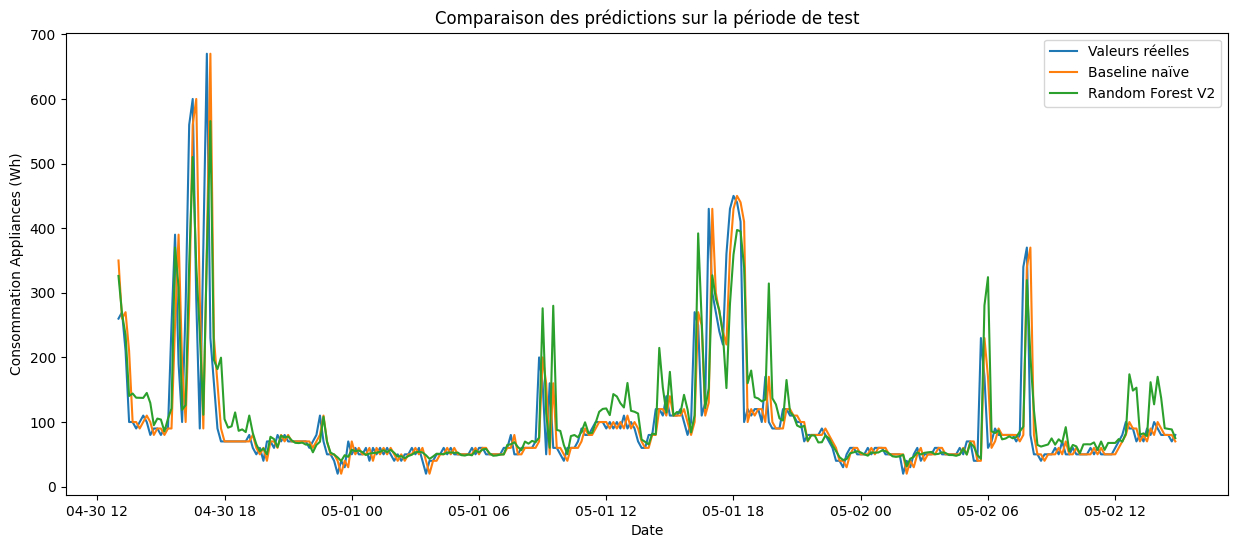

In [106]:
n_points = 300

dates_test = df_forecast["date"].iloc[split_index:]

plt.figure(figsize=(15, 6))

plt.plot(
    dates_test.iloc[:n_points],
    y_test_forecast.iloc[:n_points],
    label="Valeurs réelles"
)

plt.plot(
    dates_test.iloc[:n_points],
    y_pred_naive.iloc[:n_points],
    label="Baseline naïve"
)

plt.plot(
    dates_test.iloc[:n_points],
    y_pred_forecast_v2[:n_points],
    label="Random Forest V2"
)

plt.xlabel("Date")
plt.ylabel("Consommation Appliances (Wh)")
plt.title("Comparaison des prédictions sur la période de test")
plt.legend()

plt.show()

### Interprétation visuelle des prédictions

La visualisation confirme les résultats obtenus avec les métriques.

La baseline naïve suit très étroitement les valeurs réelles, notamment lors des variations rapides de consommation. Cela s'explique par la forte dépendance entre deux observations successives.

Le Random Forest V2 reproduit globalement la tendance de la série, mais il peine davantage à suivre certains pics et variations brusques. Il peut également produire des écarts importants lors de périodes de forte consommation.

Cette visualisation confirme donc que, sur cet horizon de prévision très court, la stratégie de persistance reste plus efficace que le Random Forest testé.

### Analyse des erreurs de prévision

Après avoir comparé visuellement les valeurs réelles et les prédictions, nous analysons maintenant les erreurs du modèle.

L'objectif est d'identifier les moments où les prédictions s'écartent le plus des valeurs réelles, notamment lors des pics de consommation.

In [107]:
errors_naive = y_test_forecast.values - y_pred_naive.values
errors_rf_v2 = y_test_forecast.values - y_pred_forecast_v2

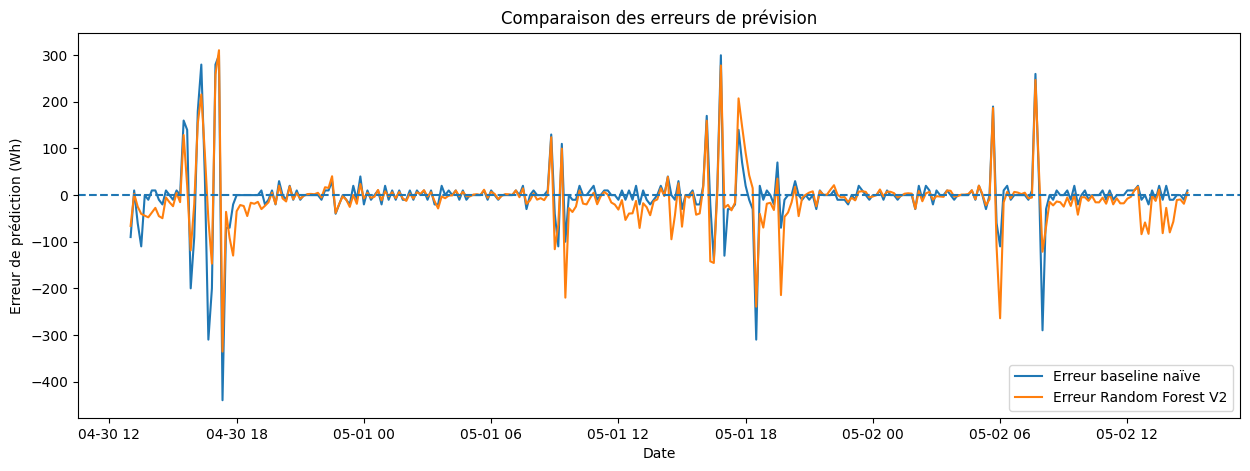

In [108]:
n_points = 300

plt.figure(figsize=(15, 5))

plt.plot(
    dates_test.iloc[:n_points],
    errors_naive[:n_points],
    label="Erreur baseline naïve"
)

plt.plot(
    dates_test.iloc[:n_points],
    errors_rf_v2[:n_points],
    label="Erreur Random Forest V2"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Erreur de prédiction (Wh)")
plt.title("Comparaison des erreurs de prévision")
plt.legend()

plt.show()

### Interprétation des erreurs de prévision

L'analyse des erreurs confirme que la baseline naïve reste globalement plus stable que le Random Forest V2.

Les deux approches rencontrent des difficultés lors de variations brusques de consommation, mais les erreurs du Random Forest sont plus fréquentes et souvent plus importantes.

Les principaux écarts apparaissent lors des pics de consommation, ce qui montre que ces événements restent difficiles à anticiper avec les variables utilisées.

Cette analyse confirme que, sur cet horizon de prévision très court, la stratégie de persistance constitue une référence difficile à dépasser.

## Conclusion générale

Ce projet m’a permis de suivre plusieurs étapes d’un projet de Data Science, depuis l’exploration des données jusqu’à la comparaison de plusieurs modèles de prédiction.

Dans un premier temps, j’ai analysé les données de consommation énergétique et étudié l’influence des différentes variables disponibles. J’ai ensuite testé une régression linéaire puis un Random Forest. Sur une séparation aléatoire des données, le Random Forest obtenait de meilleures performances que la régression linéaire, ce qui montrait que les relations entre les variables et la consommation n’étaient pas uniquement linéaires.

En poursuivant l’analyse, j’ai voulu vérifier si ces performances restaient valables lorsqu’on respectait l’ordre chronologique des données. La validation temporelle a montré que les résultats étaient beaucoup moins bons. Cela m’a amenée à reformuler le problème comme un problème de forecasting.

J’ai alors créé plusieurs variables temporelles, notamment des lag features et des moyennes glissantes, puis testé différentes approches comme le Random Forest et le Gradient Boosting. J’ai également comparé ces modèles à une baseline naïve qui utilise simplement la consommation observée 10 minutes auparavant.

Les résultats ont montré que cette baseline simple restait plus performante que les modèles plus complexes sur la période de test. L’analyse d’autocorrélation a confirmé que la consommation est fortement liée aux observations très récentes.

Ce projet m’a surtout permis de comprendre qu’un modèle plus complexe n’est pas forcément meilleur et qu’il est important de choisir une méthode de validation adaptée à la nature des données. Il m’a aussi permis de travailler sur des notions importantes comme le feature engineering temporel, la validation croisée, les métriques d’évaluation, l’autocorrélation et la comparaison de modèles.

Même si les modèles de forecasting testés n’ont pas dépassé la baseline naïve, cette étape m’a permis d’identifier les limites de l’approche utilisée et de mieux comprendre la difficulté de la prévision de séries temporelles.

Une limite de cette approche concerne également les variables environnementales utilisées au moment de la prévision. Dans une application réelle, il faudrait vérifier quelles informations sont réellement disponibles au moment où la prédiction est effectuée et, si nécessaire, utiliser leurs valeurs retardées ou prévues.